In [ ]:
!gdown 1KuDLpUaSe0wzDWEhgG0wKXV1_AVmzLK4
!unzip ./dataset.zip -d .

Downloading...
From: https://drive.google.com/uc?id=1KuDLpUaSe0wzDWEhgG0wKXV1_AVmzLK4
To: /content/dataset.zip
100% 928k/928k [00:00<00:00, 161MB/s]
Archive:  ./dataset.zip
   creating: ./dataset/
   creating: ./dataset/private_test/
  inflating: ./dataset/private_test/private_test.zh  
   creating: ./dataset/public_test/
  inflating: ./dataset/public_test/public_test.zh  
   creating: ./dataset/train/
  inflating: ./dataset/train/train.vi  
  inflating: ./dataset/train/train.zh  


In [ ]:
!pip install -qq sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.0 MB/s eta 0:00:00


In [ ]:
import os
import random
import sentencepiece as spm
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import math
from dataclasses import dataclass
from typing import List, Tuple, Any, Dict, Optional

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
import torch.optim as optim
import sacrebleu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

In [ ]:
BASE_DIR = "."
TRAIN_DIR = os.path.join(BASE_DIR, "dataset", "train")
SRC_FILE = os.path.join(TRAIN_DIR, "train.zh")
TGT_FILE = os.path.join(TRAIN_DIR, "train.vi")
TOKENIZER_DIR = os.path.join(BASE_DIR, "tokenizer_train32")
TOKENIZER_PREFIX = os.path.join(TOKENIZER_DIR, "spm_zh_vi_joint")
MAX_TOKENS = 32
VOCAB_SIZE = 8000
USER_SYMBOLS = ["<2zh>", "<2vi>"]

os.makedirs(TOKENIZER_DIR, exist_ok=True)

In [ ]:
# ----- LOAD -----
def load_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [l.strip() for l in f if l.strip()]

zh_lines = load_lines(SRC_FILE)
vi_lines = load_lines(TGT_FILE)

assert len(zh_lines) == len(vi_lines), "Số câu zh và vi không khớp!"
print(f"Tổng số cặp song ngữ: {len(zh_lines):,}")

# ----- PREVIEW -----
pd.DataFrame({"zh": zh_lines[:5], "vi": vi_lines[:5]})


Tổng số cặp song ngữ: 32,061


,zh,vi
0,我 会 给 您 拿 一些 。,Tôi sẽ mang cho bạn một_ít .
1,如果 你 还 有 什么 需要 的 就 告诉 我 。,Nếu bạn cần điều gì khác hãy cho tôi biết .
2,不用 担心 那件 事 。,Đừng lo_lắng về điều đó .
3,我 要 买 它 你 不 需要 把 它 包 起来 。,Tôi sẽ mang nó và bạn không cần phải gói nó lại .
4,你 改变 吗 ？,Bạn thay_đổi không ?


ZH: mean=7.38, min=1, max=40
VI: mean=8.24, min=1, max=48


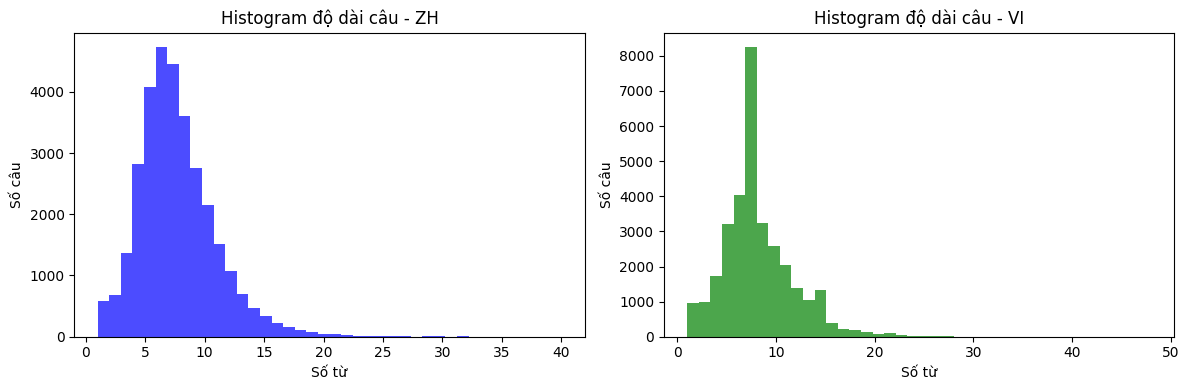

In [ ]:
# ----- STATS -----
zh_len = np.array([len(s.split()) for s in zh_lines])
vi_len = np.array([len(s.split()) for s in vi_lines])

print(f"ZH: mean={zh_len.mean():.2f}, min={zh_len.min()}, max={zh_len.max()}")
print(f"VI: mean={vi_len.mean():.2f}, min={vi_len.min()}, max={vi_len.max()}")

# ----- PLOT -----
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(zh_len, bins=40, color='blue', alpha=0.7)
plt.title("Histogram độ dài câu - ZH")
plt.xlabel("Số từ")
plt.ylabel("Số câu")

plt.subplot(1,2,2)
plt.hist(vi_len, bins=40, color='green', alpha=0.7)
plt.title("Histogram độ dài câu - VI")
plt.xlabel("Số từ")
plt.ylabel("Số câu")

plt.tight_layout()
plt.show()

In [ ]:
temp_corpus = os.path.join(TOKENIZER_DIR, "temp_corpus.txt")
with open(temp_corpus, "w", encoding="utf-8") as fout:
    for zh, vi in zip(zh_lines, vi_lines):
        fout.write(zh + "\n")
        fout.write(vi + "\n")

spm_args = (
    f"--input={temp_corpus} ",
    f"--model_prefix={TOKENIZER_PREFIX} ",
    f"--vocab_size={VOCAB_SIZE} ",
    f"--model_type=bpe ",
    f"--character_coverage=1.0 ",
    "--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 ",
    f"--user_defined_symbols={','.join(USER_SYMBOLS)}"
 )
spm.SentencePieceTrainer.Train(' '.join(spm_args))

print(f"Tokenizer saved to {TOKENIZER_PREFIX}.model")

Tokenizer saved to ./tokenizer_train32/spm_zh_vi_joint.model


In [ ]:
# Load tokenizer
sp = spm.SentencePieceProcessor()
sp.Load(f"{TOKENIZER_PREFIX}.model")

# Load raw dataset
def load_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [l.strip() for l in f if l.strip()]

zh_lines = load_lines(SRC_FILE)
vi_lines = load_lines(TGT_FILE)
assert len(zh_lines) == len(vi_lines)

MAX_TOK = 32

def tok_len(t, prefix=None):
    if prefix:
        t = f"{prefix} {t}"
    return len(sp.encode(t, out_type=int))

# Token length BEFORE filtering
zh_before = [tok_len(z, "<2vi>") for z in zh_lines]
vi_before = [tok_len(v) for v in vi_lines]

# Filter sample dài
filtered_zh, filtered_vi = [], []
for z, v in zip(zh_lines, vi_lines):
    if tok_len(z, "<2vi>") <= MAX_TOK and tok_len(v) <= MAX_TOK:
        filtered_zh.append(z)
        filtered_vi.append(v)


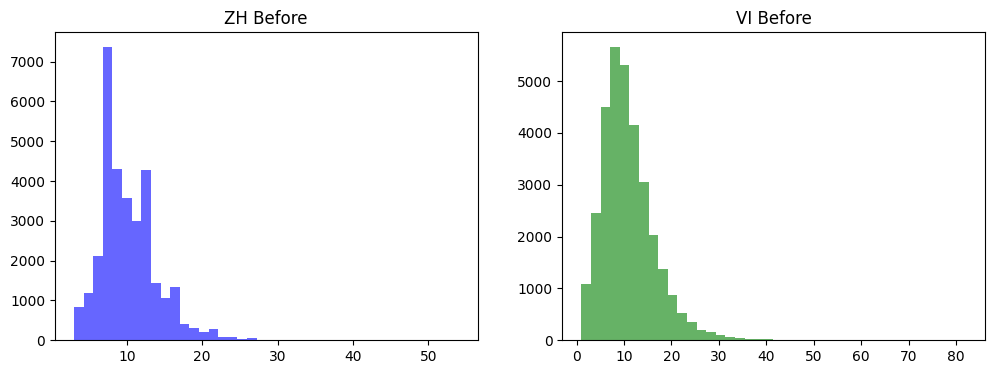

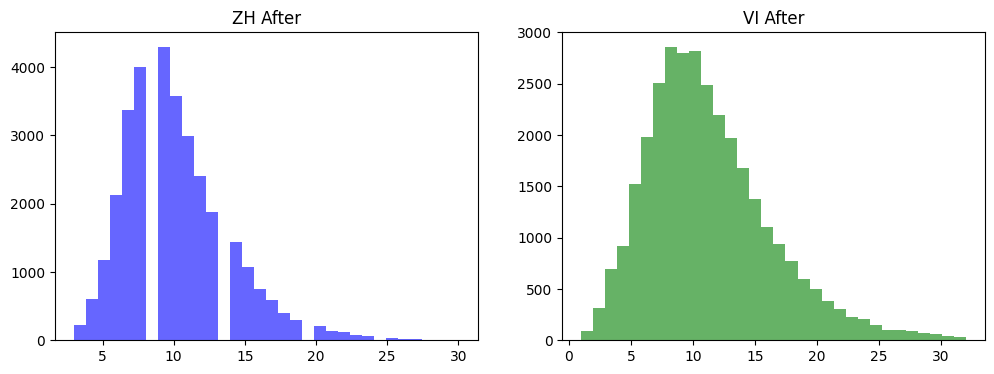

In [ ]:
zh_after = np.array([tok_len(z, "<2vi>") for z in filtered_zh])
vi_after = np.array([tok_len(v) for v in filtered_vi])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.hist(zh_before, bins=40, color='blue', alpha=0.6); plt.title("ZH Before")
plt.subplot(1,2,2); plt.hist(vi_before, bins=40, color='green', alpha=0.6); plt.title("VI Before")
plt.show()

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.hist(zh_after, bins=32, color='blue', alpha=0.6); plt.title("ZH After")
plt.subplot(1,2,2); plt.hist(vi_after, bins=32, color='green', alpha=0.6); plt.title("VI After")
plt.show()


In [ ]:
OUT_DIR = "./clean_data"
os.makedirs(OUT_DIR, exist_ok=True)

zh_out = os.path.join(OUT_DIR, f"train_maxlen{MAX_TOK}.zh")
vi_out = os.path.join(OUT_DIR, f"train_maxlen{MAX_TOK}.vi")

with open(zh_out, "w", encoding="utf-8") as fzh:
    fzh.write("\n".join(filtered_zh))

with open(vi_out, "w", encoding="utf-8") as fvi:
    fvi.write("\n".join(filtered_vi))

# ---- PRINT THÔNG TIN QUAN TRỌNG ----
total_before = len(zh_lines)
total_after = len(filtered_zh)

print(f"Saved cleaned dataset into: {OUT_DIR}")
print(f"ZH file: {zh_out}  ({total_after} lines)")
print(f"VI file: {vi_out}  ({total_after} lines)")
print(f"Filter kept: {total_after:,} / {total_before:,}")
print(f"MAX_TOKENS limit = {MAX_TOK}")


Saved cleaned dataset into: ./clean_data
ZH file: ./clean_data/train_maxlen32.zh  (31874 lines)
VI file: ./clean_data/train_maxlen32.vi  (31874 lines)
Filter kept: 31,874 / 32,061
MAX_TOKENS limit = 32


In [ ]:
# --- Config ---
@dataclass
class RopeConfig:
    train_src_file: str
    train_tgt_file: str
    spm_prefix: str
    train_back_dir: str = OUT_DIR
    vocab_size: int = 8000
    d_model: int = 768
    n_heads: int = 12
    n_kv_heads: int = 4
    num_encoder_layers: int = 8
    num_decoder_layers: int = 8
    d_ff: int = 3072
    dropout: float = 0.01
    max_len: int = 32
    rope_base: float = 10000.0
    pad_token: str = "<pad>"
    bos_token: str = "<s>"
    eos_token: str = "</s>"
    unk_token: str = "<unk>"
    zh_token: str = "<2zh>"
    vi_token: str = "<2vi>"
    batch_size: int = 128
    num_epochs: int = 40
    lr_base: float = 2e-4
    warmup_steps: int = 200
    weight_decay: float = 0.01
    label_smoothing: float = 0.01
    grad_clip: float = 1.0
    span_mask_prob: float = 0.01
    vi2zh_epoch_ratio: float = 0.7
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_workers: int = 8
    save_dir: str = "./checkpoints_bidirectional"
    save_every: int = 10
    seed: int = 42


config = RopeConfig(
    train_src_file=os.path.join(OUT_DIR, f"train_maxlen{MAX_TOK}.zh"),
    train_tgt_file=os.path.join(OUT_DIR, f"train_maxlen{MAX_TOK}.vi"),
    spm_prefix=TOKENIZER_PREFIX,
)

random.seed(config.seed)
torch.manual_seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)

os.makedirs(config.save_dir, exist_ok=True)

sp_model = spm.SentencePieceProcessor()
sp_model.Load(f"{config.spm_prefix}.model")
vocab_size = sp_model.GetPieceSize()


def read_lines(path: str) -> List[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


src_lines = read_lines(config.train_src_file)
tgt_lines = read_lines(config.train_tgt_file)
assert len(src_lines) == len(tgt_lines), "Song ngữ không cân bằng"

split_idx = int(0.95 * len(src_lines))
if split_idx % 2 != 0:
    split_idx -= 1
split_idx = max(split_idx, 0)

train_src_lines = src_lines[:split_idx]
train_tgt_lines = tgt_lines[:split_idx]

valid_src_lines, valid_tgt_lines = [], []
valid_src_all = src_lines[split_idx:]
valid_tgt_all = tgt_lines[split_idx:]
for i in range(0, len(valid_src_all), 2):
    if i < len(valid_src_all):
        valid_src_lines.append(valid_src_all[i])
        valid_tgt_lines.append(valid_tgt_all[i])

print(f"Tokenizer vocab size: {vocab_size}")
print(f"Train samples: {len(train_src_lines)} | Valid samples: {len(valid_src_lines)}")
print(f"Config device: {config.device}")

Tokenizer vocab size: 8000
Train samples: 30280 | Valid samples: 797
Config device: cuda


In [ ]:
class BidirectionalTranslationDataset(Dataset):
    """Sinh dữ liệu hai chiều ZH↔VI với span masking."""

    def __init__(
        self,
        src_lines: List[str],
        tgt_lines: List[str],
        sp_model: spm.SentencePieceProcessor,
        config: RopeConfig,
        is_training: bool = True,
    ):
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines
        self.sp = sp_model
        self.config = config
        self.is_training = is_training

        self.pad_id = sp_model.piece_to_id(config.pad_token)
        self.bos_id = sp_model.piece_to_id(config.bos_token)
        self.eos_id = sp_model.piece_to_id(config.eos_token)
        self.unk_id = sp_model.piece_to_id(config.unk_token)
        self.zh_id = sp_model.piece_to_id(config.zh_token)
        self.vi_id = sp_model.piece_to_id(config.vi_token)

        self.samples = []
        if is_training:
            for i, (src, tgt) in enumerate(zip(src_lines, tgt_lines)):
                if i % 2 == 0:
                    self.samples.append((self.add_lang_token(src, config.vi_token), tgt, "zh2vi"))
                else:
                    self.samples.append((self.add_lang_token(src, config.zh_token), tgt, "vi2zh"))
        else:
            for src, tgt in zip(src_lines, tgt_lines):
                self.samples.append((self.add_lang_token(src, config.vi_token), tgt, "zh2vi"))

        self.zh2vi_indices = [idx for idx, (_, _, d) in enumerate(self.samples) if d == "zh2vi"]
        self.vi2zh_indices = [idx for idx, (_, _, d) in enumerate(self.samples) if d == "vi2zh"]

    def add_lang_token(self, text: str, lang_tok: str) -> str:
        text = text.strip()
        if text.startswith("<2vi>") or text.startswith("<2zh>"):
            return text
        return f"{lang_tok} {text}"

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        src_text, tgt_text, _ = self.samples[idx]
        src_ids = self.sp.encode(src_text, out_type=int)[: self.config.max_len]
        tgt_ids = [self.bos_id] + self.sp.encode(tgt_text, out_type=int) + [self.eos_id]
        tgt_ids = tgt_ids[: self.config.max_len]
        src_ids = self.apply_span_masking(src_ids)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)

    def apply_span_masking(self, src_ids: List[int]) -> List[int]:
        if not self.is_training or random.random() > self.config.span_mask_prob:
            return src_ids
        src_ids = src_ids.copy()
        special = {self.pad_id, self.bos_id, self.eos_id, self.zh_id, self.vi_id}
        maskable = [i for i, t in enumerate(src_ids) if t not in special]
        if not maskable:
            return src_ids
        num_to_mask = min(random.randint(1, 2), len(maskable))
        start = random.choice(maskable)
        for i in range(start, min(start + num_to_mask, len(src_ids))):
            if i in maskable and random.random() < 0.7:
                src_ids[i] = self.unk_id
        return src_ids


def collate_fn(batch):
    src_list, tgt_list = zip(*batch)
    max_src = max(len(s) for s in src_list)
    max_tgt = max(len(t) for t in tgt_list)
    src_batch = torch.zeros(len(batch), max_src, dtype=torch.long)
    tgt_batch = torch.zeros(len(batch), max_tgt, dtype=torch.long)
    for i, (src, tgt) in enumerate(zip(src_list, tgt_list)):
        src_batch[i, : len(src)] = src
        tgt_batch[i, : len(tgt)] = tgt
    return src_batch, tgt_batch


def select_vi2zh_window(indices: List[int], epoch: int, ratio: float) -> List[int]:
    if not indices or ratio <= 0:
        return []
    total = len(indices)
    window = max(1, int(math.ceil(total * min(ratio, 1.0))))
    start = ((epoch - 1) * window) % total
    end = start + window
    if end <= total:
        return indices[start:end]
    wrap = end - total
    return indices[start:] + indices[:wrap]


train_dataset = BidirectionalTranslationDataset(train_src_lines, train_tgt_lines, sp_model, config, True)
valid_dataset = BidirectionalTranslationDataset(valid_src_lines, valid_tgt_lines, sp_model, config, False)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=config.num_workers,
    pin_memory=True,
)


def build_train_loader(epoch: int) -> Tuple[DataLoader, int]:
    active = list(train_dataset.zh2vi_indices)
    vi_slice = select_vi2zh_window(train_dataset.vi2zh_indices, epoch, config.vi2zh_epoch_ratio)
    active.extend(vi_slice)
    sampler = SubsetRandomSampler(active)
    loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        sampler=sampler,
        collate_fn=collate_fn,
        num_workers=config.num_workers,
        pin_memory=True,
    )
    return loader, len(vi_slice)


print(
    f"Dataset ready | total={len(train_dataset)} | zh→vi={len(train_dataset.zh2vi_indices)} | vi→zh={len(train_dataset.vi2zh_indices)}"
)
print(f"Valid batches: {len(valid_loader)}")

Dataset ready | total=30280 | zh→vi=15140 | vi→zh=15140
Valid batches: 4


In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        return self.weight * x / rms


class RoPE(nn.Module):
    def __init__(self, d_model: int, base: float = 10000.0):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, d_model, 2).float() / d_model))
        self.register_buffer("inv_freq", inv_freq)
        self._cos = None
        self._sin = None
        self._seq_len_cached = 0

    def _maybe_update_cache(self, seq_len: int, device, dtype):
        if seq_len > self._seq_len_cached or self._cos is None or self._cos.device != device:
            self._seq_len_cached = seq_len
            positions = torch.arange(seq_len, device=device, dtype=dtype)
            freqs = torch.outer(positions, self.inv_freq.to(device))
            self._cos = freqs.cos()
            self._sin = freqs.sin()

    def forward(self, x: torch.Tensor, seq_len: Optional[int] = None):
        seq_len = seq_len or x.size(-2)
        self._maybe_update_cache(seq_len, x.device, x.dtype)
        return self._cos[:seq_len], self._sin[:seq_len]


def apply_rope(x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
    x1 = x[..., 0::2]
    x2 = x[..., 1::2]
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)
    rot1 = x1 * cos - x2 * sin
    rot2 = x1 * sin + x2 * cos
    return torch.stack([rot1, rot2], dim=-1).flatten(-2)


class FFN_SwiGLU(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.d_ff = d_ff
        self.linear1 = nn.Linear(d_model, 2 * d_ff, bias=False)
        self.linear2 = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.linear1(x)
        g, v = h[..., : self.d_ff], h[..., self.d_ff :]
        s = g * torch.sigmoid(g)
        out = self.linear2(s * v)
        return self.dropout(out)


class GroupedQueryAttentionRoPE(nn.Module):
    def __init__(self, d_model: int, n_heads: int, n_kv_heads: int, dropout: float, rope_base: float):
        super().__init__()
        assert n_heads % n_kv_heads == 0
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_groups = n_heads // n_kv_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, n_heads * self.d_k, bias=False)
        self.W_k = nn.Linear(d_model, n_kv_heads * self.d_k, bias=False)
        self.W_v = nn.Linear(d_model, n_kv_heads * self.d_k, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)
        self.rope = RoPE(self.d_k, base=rope_base)

    def forward(self, q, k, v, key_padding_mask=None, attn_mask=None):
        B, T_q = q.size(0), q.size(1)
        T_k = k.size(1)
        Q = self.W_q(q).view(B, T_q, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(B, T_k, self.n_kv_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(B, T_k, self.n_kv_heads, self.d_k).transpose(1, 2)
        cos_q, sin_q = self.rope(Q, T_q)
        cos_k, sin_k = self.rope(K, T_k)
        Q = apply_rope(Q, cos_q, sin_q)
        K = apply_rope(K, cos_k, sin_k)
        K = K.repeat_interleave(self.n_groups, dim=1)
        V = V.repeat_interleave(self.n_groups, dim=1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask.unsqueeze(0).unsqueeze(0), float("-inf"))
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, T_q, -1)
        return self.W_o(out)


class EncoderLayer(nn.Module):
    def __init__(self, config: RopeConfig):
        super().__init__()
        self.ln1 = RMSNorm(config.d_model)
        self.self_attn = GroupedQueryAttentionRoPE(
            config.d_model, config.n_heads, config.n_kv_heads, config.dropout, config.rope_base
        )
        self.ln2 = RMSNorm(config.d_model)
        self.ffn = FFN_SwiGLU(config.d_model, config.d_ff, config.dropout)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, src_pad_mask=None):
        x1 = self.ln1(x)
        attn = self.self_attn(x1, x1, x1, key_padding_mask=src_pad_mask)
        x = x + self.dropout(attn)
        x2 = self.ln2(x)
        return x + self.ffn(x2)


class DecoderLayer(nn.Module):
    def __init__(self, config: RopeConfig):
        super().__init__()
        self.ln1 = RMSNorm(config.d_model)
        self.self_attn = GroupedQueryAttentionRoPE(
            config.d_model, config.n_heads, config.n_kv_heads, config.dropout, config.rope_base
        )
        self.ln2 = RMSNorm(config.d_model)
        self.cross_attn = GroupedQueryAttentionRoPE(
            config.d_model, config.n_heads, config.n_kv_heads, config.dropout, config.rope_base
        )
        self.ln3 = RMSNorm(config.d_model)
        self.ffn = FFN_SwiGLU(config.d_model, config.d_ff, config.dropout)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, y, enc_out, tgt_pad_mask=None, tgt_causal_mask=None, src_pad_mask=None):
        y1 = self.ln1(y)
        self_attn = self.self_attn(
            y1, y1, y1,
            key_padding_mask=tgt_pad_mask,
            attn_mask=tgt_causal_mask,
        )
        y = y + self.dropout(self_attn)
        y2 = self.ln2(y)
        cross_attn = self.cross_attn(y2, enc_out, enc_out, key_padding_mask=src_pad_mask)
        y = y + self.dropout(cross_attn)
        y3 = self.ln3(y)
        return y + self.ffn(y3)


class TransformerModel(nn.Module):
    def __init__(self, config: RopeConfig, vocab_size: int):
        super().__init__()
        self.config = config
        self.embedding = nn.Embedding(vocab_size, config.d_model, padding_idx=0)
        self.emb_dropout = nn.Dropout(config.dropout)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.num_encoder_layers)])
        self.encoder_final_ln = RMSNorm(config.d_model)
        self.decoder_layers = nn.ModuleList([DecoderLayer(config) for _ in range(config.num_decoder_layers)])
        self.decoder_final_ln = RMSNorm(config.d_model)
        self.output_bias = nn.Parameter(torch.zeros(vocab_size))
        self.emb_scale = math.sqrt(config.d_model)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src_ids: torch.Tensor, tgt_ids: torch.Tensor) -> torch.Tensor:
        src_pad = (src_ids == 0)
        tgt_pad = (tgt_ids == 0)
        tgt_in = tgt_ids[:, :-1]
        tgt_pad_in = tgt_pad[:, :-1]
        T = tgt_in.size(1)
        tgt_causal = torch.triu(torch.ones(T, T, dtype=torch.bool, device=src_ids.device), diagonal=1)
        src_emb = self.emb_dropout(self.embedding(src_ids) * self.emb_scale)
        enc_out = src_emb
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_pad)
        enc_out = self.encoder_final_ln(enc_out)
        tgt_emb = self.emb_dropout(self.embedding(tgt_in) * self.emb_scale)
        dec_out = tgt_emb
        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, tgt_pad_in, tgt_causal, src_pad)
        dec_out = self.decoder_final_ln(dec_out)
        return F.linear(dec_out, self.embedding.weight, self.output_bias)

In [ ]:
class LabelSmoothedCrossEntropyLoss(nn.Module):
    def __init__(self, smoothing: float = 0.1, ignore_index: int = 0):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        vocab_size = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        mask = targets != self.ignore_index
        with torch.no_grad():
            true_dist = torch.full_like(
                log_probs, self.smoothing / (vocab_size - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
            true_dist[targets == self.ignore_index] = 0.0
        loss = -(true_dist * log_probs).sum(dim=-1)
        loss = loss.masked_fill(~mask, 0.0)
        return loss.sum() / mask.sum().clamp(min=1)


class WarmupInverseSqrtScheduler:
    def __init__(self, optimizer, warmup_steps: int, lr_base: float):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.lr_base = lr_base
        self.step_num = 0

    def step(self):
        self.step_num += 1
        if self.step_num <= self.warmup_steps:
            lr = self.lr_base * self.step_num / self.warmup_steps
        else:
            lr = self.lr_base * math.sqrt(self.warmup_steps) / math.sqrt(self.step_num)
        for group in self.optimizer.param_groups:
            group["lr"] = lr

    def get_lr(self):
        return self.optimizer.param_groups[0]["lr"]


def train_epoch(model, dataloader, criterion, optimizer, scheduler, config: RopeConfig, epoch: int) -> float:
    model.train()
    total_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}")
    for src_batch, tgt_batch in pbar:
        src_batch = src_batch.to(config.device)
        tgt_batch = tgt_batch.to(config.device)
        logits = model(src_batch, tgt_batch)
        targets = tgt_batch[:, 1:]
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_lr():.6f}")
    return total_loss / len(dataloader)


@dataclass
class BeamSearchHypothesis:
    tokens: list
    log_prob: float


@torch.no_grad()
def greedy_decode(
    model: TransformerModel,
    src_ids: torch.Tensor,
    sp_model: spm.SentencePieceProcessor,
    config: RopeConfig,
    max_len: int = 32,
):
    """Fast greedy decoding for validation BLEU calculation"""
    model.eval()
    batch_size = src_ids.size(0)
    device = src_ids.device
    bos = sp_model.piece_to_id(config.bos_token)
    eos = sp_model.piece_to_id(config.eos_token)
    pad = sp_model.piece_to_id(config.pad_token)

    # Encode source
    src_pad_mask = (src_ids == pad)
    src_emb = model.embedding(src_ids) * model.emb_scale
    src_input = model.emb_dropout(src_emb)
    enc_out = src_input
    for layer in model.encoder_layers:
        enc_out = layer(enc_out, src_pad_mask)
    enc_out = model.encoder_final_ln(enc_out)

    # Initialize decoder input
    tgt_ids = torch.full((batch_size, 1), bos, dtype=torch.long, device=device)

    for _ in range(max_len):
        tgt_pad = (tgt_ids == pad)
        tgt_len = tgt_ids.size(1)
        tgt_causal = torch.triu(torch.ones(tgt_len, tgt_len, dtype=torch.bool, device=device), diagonal=1)

        tgt_emb = model.embedding(tgt_ids) * model.emb_scale
        tgt_input = model.emb_dropout(tgt_emb)
        dec_out = tgt_input
        for layer in model.decoder_layers:
            dec_out = layer(dec_out, enc_out, tgt_pad, tgt_causal, src_pad_mask)
        dec_out = model.decoder_final_ln(dec_out)

        logits = F.linear(dec_out, model.embedding.weight, model.output_bias)
        next_tokens = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        tgt_ids = torch.cat([tgt_ids, next_tokens], dim=1)

        # Stop if all sequences have EOS
        if (next_tokens.squeeze(-1) == eos).all():
            break

    # Decode to text
    decoded = []
    for seq in tgt_ids:
        tokens = seq[1:].cpu().tolist()  # Skip BOS
        if eos in tokens:
            tokens = tokens[:tokens.index(eos)]
        decoded.append(sp_model.decode(tokens))

    return decoded


@torch.no_grad()
def beam_search_decode(
    model: TransformerModel,
    src_ids: torch.Tensor,
    sp_model: spm.SentencePieceProcessor,
    config: RopeConfig,
    beam_size: int = 3,
    top_k: int = 3,
    max_len: int = 32,
    length_penalty: float = 0.6,
):
    model.eval()
    batch_size = src_ids.size(0)
    device = src_ids.device
    bos = sp_model.piece_to_id(config.bos_token)
    eos = sp_model.piece_to_id(config.eos_token)
    pad = sp_model.piece_to_id(config.pad_token)
    src_pad_mask = (src_ids == pad)
    src_emb = model.embedding(src_ids) * model.emb_scale
    src_input = model.emb_dropout(src_emb)
    enc_out = src_input
    for layer in model.encoder_layers:
        enc_out = layer(enc_out, src_pad_mask)
    enc_out = model.encoder_final_ln(enc_out)
    decoded = []
    for b in range(batch_size):
        beams = [BeamSearchHypothesis(tokens=[bos], log_prob=0.0)]
        finished = []
        single_enc = enc_out[b : b + 1]
        single_mask = src_pad_mask[b : b + 1]
        for _ in range(max_len):
            new_beams = []
            for beam in beams:
                if beam.tokens[-1] == eos:
                    finished.append(beam)
                    continue
                tgt_ids = torch.tensor(beam.tokens, dtype=torch.long, device=device).unsqueeze(0)
                tgt_pad = (tgt_ids == pad)
                tgt_len = tgt_ids.size(1)
                tgt_causal = torch.triu(torch.ones(tgt_len, tgt_len, dtype=torch.bool, device=device), diagonal=1)
                tgt_emb = model.embedding(tgt_ids) * model.emb_scale
                tgt_input = model.emb_dropout(tgt_emb)
                dec_out = tgt_input
                for layer in model.decoder_layers:
                    dec_out = layer(dec_out, single_enc, tgt_pad, tgt_causal, single_mask)
                dec_out = model.decoder_final_ln(dec_out)
                logits = F.linear(dec_out, model.embedding.weight, model.output_bias)
                log_probs = F.log_softmax(logits[:, -1, :], dim=-1)
                if top_k and top_k > 0:
                    top_val, top_idx = torch.topk(log_probs, min(top_k, log_probs.size(-1)))
                    mask = torch.full_like(log_probs, float("-inf"))
                    mask.scatter_(1, top_idx, top_val)
                    log_probs = mask
                top_vals, top_idx = torch.topk(log_probs.squeeze(0), beam_size)
                for val, idx in zip(top_vals.tolist(), top_idx.tolist()):
                    new_beams.append(BeamSearchHypothesis(tokens=beam.tokens + [idx], log_prob=beam.log_prob + val))
            beams = sorted(new_beams, key=lambda h: h.log_prob, reverse=True)[:beam_size]
            if not beams:
                break
        finished.extend(beams)
        best = max(finished, key=lambda h: h.log_prob / (len(h.tokens) ** length_penalty))
        tokens = best.tokens[1:]
        if eos in tokens:
            tokens = tokens[: tokens.index(eos)]
        decoded.append(sp_model.decode(tokens))
    return decoded


@torch.no_grad()
def evaluate(model, dataloader, criterion, sp_model, config: RopeConfig, calculate_bleu: bool = True, max_bleu_samples: int = 500):
    """
    Fast evaluation with optional BLEU calculation
    Args:
        calculate_bleu: Whether to calculate BLEU score (slower)
        max_bleu_samples: Maximum number of samples for BLEU calculation
    """
    model.eval()
    total_loss = 0.0
    all_predictions, all_references = [], []

    bleu_count = 0
    for i, (src_batch, tgt_batch) in enumerate(tqdm(dataloader, desc="Evaluating", leave=False)):
        src_batch = src_batch.to(config.device)
        tgt_batch = tgt_batch.to(config.device)

        # Always calculate loss
        logits = model(src_batch, tgt_batch)
        targets = tgt_batch[:, 1:]
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        total_loss += loss.item()

        # Only calculate BLEU on subset for speed
        if calculate_bleu and bleu_count < max_bleu_samples:
            # Use greedy decoding instead of beam search for speed
            preds = greedy_decode(model, src_batch, sp_model, config, max_len=config.max_len)

            eos = sp_model.piece_to_id(config.eos_token)
            for tgt_seq in tgt_batch:
                ref = tgt_seq[1:].cpu().tolist()
                if eos in ref:
                    ref = ref[: ref.index(eos)]
                all_references.append(sp_model.decode(ref))

            all_predictions.extend(preds)
            bleu_count += len(preds)

            # Stop if we have enough samples for BLEU
            if bleu_count >= max_bleu_samples:
                break

    avg_loss = total_loss / len(dataloader)
    bleu_score = 0.0

    if calculate_bleu and sacrebleu is not None and all_predictions:
        try:
            bleu = sacrebleu.corpus_bleu(all_predictions, [all_references], force=True)
            bleu_score = bleu.score
        except Exception as err:
            print(f"BLEU calculation failed: {err}")

    return avg_loss, bleu_score

In [ ]:
def package_tokenizer(prefix: str) -> Dict[str, Any]:
    model_path = f"{prefix}.model"
    vocab_path = f"{prefix}.vocab"
    if not (os.path.isfile(model_path) and os.path.isfile(vocab_path)):
        raise FileNotFoundError(f"Missing tokenizer files at {prefix}.[model|vocab]")
    with open(model_path, "rb") as f:
        model_bytes = f.read()
    with open(vocab_path, "rb") as f:
        vocab_bytes = f.read()
    return {"prefix": prefix, "model_bytes": model_bytes, "vocab_bytes": vocab_bytes}


model = TransformerModel(config, vocab_size).to(config.device)
criterion = LabelSmoothedCrossEntropyLoss(config.label_smoothing, ignore_index=0)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.lr_base,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=config.weight_decay,
)
scheduler = WarmupInverseSqrtScheduler(optimizer, config.warmup_steps, config.lr_base)
tokenizer_payload = package_tokenizer(config.spm_prefix)

print(f"Model params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Saving checkpoints to: {config.save_dir}")

best_val_loss = float("inf")
best_val_bleu = 0.0

for epoch in range(1, config.num_epochs + 1):
    train_loader, vi_slice_len = build_train_loader(epoch)
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, config, epoch)

    # Calculate BLEU every epoch
    val_loss, val_bleu = evaluate(
        model, valid_loader, criterion, sp_model, config,
        calculate_bleu=True, max_bleu_samples=300  # Reduced sample size
    )

    print(f"\nEpoch {epoch}/{config.num_epochs}")
    print(f"  vi→zh coverage: {vi_slice_len}/{len(train_dataset.vi2zh_indices)} (~{100 * config.vi2zh_epoch_ratio:.1f}% per epoch)")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Valid Loss: {val_loss:.4f}")
    print(f"  Valid BLEU: {val_bleu:.2f}")
    print(f"  Learning Rate: {scheduler.get_lr():.6f}")

    if epoch % config.save_every == 0:
        ckpt_path = os.path.join(config.save_dir, f"checkpoint_epoch_{epoch}.pt")
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_bleu": val_bleu,
                "config": config,
                "tokenizer": tokenizer_payload,
            },
            ckpt_path,
        )
        print(f"  ✓ Saved checkpoint to {ckpt_path}")

    # Update best model based on validation loss (always available)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_bleu = val_bleu

        best_path = os.path.join(config.save_dir, "best_model.pt")
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_bleu": best_val_bleu,
                "config": config,
                "tokenizer": tokenizer_payload,
            },
            best_path,
        )

print("\nTraining finished.")
print(f"Best valid loss: {best_val_loss:.4f} | Best BLEU: {best_val_bleu:.2f}")

Model params: 157,179,200
Saving checkpoints to: ./checkpoints_bidirectional


Epoch 1: 100%|██████████| 101/101 [00:28<00:00,  3.49it/s, loss=4.7456, lr=0.000101]
                                                         


Epoch 1/40
  vi→zh coverage: 10598/15140 (~70.0% per epoch)
  Train Loss: 6.2664
  Valid Loss: 2.4952
  Valid BLEU: 1.50
  Learning Rate: 0.000101


Epoch 2: 100%|██████████| 101/101 [00:28<00:00,  3.51it/s, loss=3.7036, lr=0.000199]
                                                         


Epoch 2/40
  vi→zh coverage: 10598/15140 (~70.0% per epoch)
  Train Loss: 4.1094
  Valid Loss: 1.8673
  Valid BLEU: 7.86
  Learning Rate: 0.000199


...


Epoch 38/40
  vi→zh coverage: 10598/15140 (~70.0% per epoch)
  Train Loss: 0.1669
  Valid Loss: 0.8386
  Valid BLEU: 63.00
  Learning Rate: 0.000046


Epoch 39: 100%|██████████| 101/101 [00:28<00:00,  3.48it/s, loss=0.1677, lr=0.000045]
                                                         


Epoch 39/40
  vi→zh coverage: 10598/15140 (~70.0% per epoch)
  Train Loss: 0.1666
  Valid Loss: 0.8484
  Valid BLEU: 63.30
  Learning Rate: 0.000045


Epoch 40: 100%|██████████| 101/101 [00:28<00:00,  3.49it/s, loss=0.1691, lr=0.000044]
                                                         


Epoch 40/40
  vi→zh coverage: 10598/15140 (~70.0% per epoch)
  Train Loss: 0.1665
  Valid Loss: 0.8474
  Valid BLEU: 63.35
  Learning Rate: 0.000044
  ✓ Saved checkpoint to ./checkpoints_bidirectional/checkpoint_epoch_40.pt

Training finished.
Best valid loss: 0.8011 | Best BLEU: 61.50
  ✓ Saved checkpoint to ./checkpoints_bidirectional/checkpoint_epoch_40.pt

Training finished.
Best valid loss: 0.8011 | Best BLEU: 61.50


In [ ]:
# ===== CONTRASTIVE LEARNING SETUP =====

# Contrastive training config (define first to avoid memory issues)
@dataclass
class ContrastiveConfig:
    proj_dim: int = 768
    contrastive_tau: float = 0.07
    cross_lambda_max: float = 0.1
    cross_warmup_steps: int = 200
    lr_base: float = 5e-5
    warmup_steps: int = 200
    num_epochs: int = 20
    batch_size: int = 64
    save_dir: str = "./checkpoints_contrastive"
    save_every: int = 5

cl_config = ContrastiveConfig()
os.makedirs(cl_config.save_dir, exist_ok=True)

# Load checkpoint epoch 40 for contrastive training (load to CPU first)
print("Loading checkpoint for contrastive training...")
checkpoint_path = os.path.join(config.save_dir, "checkpoint_epoch_40.pt")

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Required checkpoint not found: {checkpoint_path}")

print(f"Loading checkpoint: {checkpoint_path}")
# Load to CPU first to avoid GPU memory issues
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

# Update config with smaller batch size for contrastive learning
old_config = checkpoint["config"]
config.batch_size = cl_config.batch_size  # Use smaller batch size
config.num_workers = 2  # Reduce workers

# Load model state dict
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Updated batch_size from {old_config.batch_size} to {config.batch_size}")

print(f"Contrastive config: lr={cl_config.lr_base}, epochs={cl_config.num_epochs}")
print(f"Save dir: {cl_config.save_dir}")

Loading checkpoint for contrastive training...
Loading checkpoint: ./checkpoints_bidirectional/checkpoint_epoch_40.pt


Loaded checkpoint from epoch 40
Updated batch_size from 256 to 128
Contrastive config: lr=5e-05, epochs=20
Save dir: ./checkpoints_contrastive


In [ ]:
# ===== PROJECTION HEAD & CONTRASTIVE COMPONENTS =====

import torch.nn as nn
import torch.nn.functional as F

class ProjectionHead(nn.Module):
    def __init__(self, input_dim: int, proj_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, proj_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def encode_context(model, src_ids, pad_id):
    src_pad_mask = (src_ids == pad_id)
    src_emb = model.embedding(src_ids) * model.emb_scale
    src_input = model.emb_dropout(src_emb)
    enc_out = src_input
    for layer in model.encoder_layers:
        enc_out = layer(enc_out, src_pad_mask)
    enc_out = model.encoder_final_ln(enc_out)
    return enc_out

def mean_pool(enc_out, ids, pad_id, special_ids):
    mask = (ids != pad_id)
    for special in special_ids:
        mask = mask & (ids != special)
    mask = mask.float()
    summed = (enc_out * mask.unsqueeze(-1)).sum(dim=1)
    denom = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
    return summed / denom

def contrastive_loss(z_a, z_b, tau):
    sim = torch.matmul(z_a, z_b.transpose(0, 1)) / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    loss_i = F.cross_entropy(sim, labels)
    loss_j = F.cross_entropy(sim.transpose(0, 1), labels)
    return 0.5 * (loss_i + loss_j)

# Initialize projection head
projection = ProjectionHead(config.d_model, cl_config.proj_dim).to(config.device)
print(f"Projection head: {config.d_model} -> {cl_config.proj_dim}")

# Special token IDs for pooling
special_ids = [
    sp_model.piece_to_id(config.pad_token),
    sp_model.piece_to_id(config.bos_token),
    sp_model.piece_to_id(config.eos_token),
    sp_model.piece_to_id(config.zh_token),
    sp_model.piece_to_id(config.vi_token)
]
print(f"Special token IDs: {special_ids}")

Projection head: 768 -> 768
Special token IDs: [0, 2, 3, 4, 5]


In [ ]:
# ===== PROJECTION HEAD & CONTRASTIVE COMPONENTS =====

import torch.nn as nn
import torch.nn.functional as F

class ProjectionHead(nn.Module):
    def __init__(self, input_dim: int, proj_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, proj_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def encode_context(model, src_ids, pad_id):
    src_pad_mask = (src_ids == pad_id)
    src_emb = model.embedding(src_ids) * model.emb_scale
    src_input = model.emb_dropout(src_emb)
    enc_out = src_input
    for layer in model.encoder_layers:
        enc_out = layer(enc_out, src_pad_mask)
    enc_out = model.encoder_final_ln(enc_out)
    return enc_out

def mean_pool(enc_out, ids, pad_id, special_ids):
    mask = (ids != pad_id)
    for special in special_ids:
        mask = mask & (ids != special)
    mask = mask.float()
    summed = (enc_out * mask.unsqueeze(-1)).sum(dim=1)
    denom = mask.sum(dim=1, keepdim=True).clamp(min=1.0)
    return summed / denom

def contrastive_loss(z_a, z_b, tau):
    sim = torch.matmul(z_a, z_b.transpose(0, 1)) / tau
    labels = torch.arange(sim.size(0), device=sim.device)
    loss_i = F.cross_entropy(sim, labels)
    loss_j = F.cross_entropy(sim.transpose(0, 1), labels)
    return 0.5 * (loss_i + loss_j)

# Initialize projection head
projection = ProjectionHead(config.d_model, cl_config.proj_dim).to(config.device)
print(f"Projection head: {config.d_model} -> {cl_config.proj_dim}")

# Special token IDs for pooling
special_ids = [
    sp_model.piece_to_id(config.pad_token),
    sp_model.piece_to_id(config.bos_token),
    sp_model.piece_to_id(config.eos_token),
    sp_model.piece_to_id(config.zh_token),
    sp_model.piece_to_id(config.vi_token)
]
print(f"Special token IDs: {special_ids}")

Creating contrastive dataset...


Contrastive dataset size: 31874
Contrastive batches: 250


In [ ]:
# ===== CONTRASTIVE TRAINING FUNCTIONS =====

def compute_crosslingual_loss(model, projection, ids_zh_vi, ids_vi_vi,
                      ids_vi_zh, ids_zh_zh, cl_config, pad_id, special_ids):
    if ids_zh_vi.size(0) < 2:
        return torch.zeros(1, device=config.device)

    # Encode all contexts
    enc_zh_vi = encode_context(model, ids_zh_vi, pad_id)
    enc_vi_vi = encode_context(model, ids_vi_vi, pad_id)
    enc_vi_zh = encode_context(model, ids_vi_zh, pad_id)
    enc_zh_zh = encode_context(model, ids_zh_zh, pad_id)

    # Mean pool and project
    z_zh_vi = projection(mean_pool(enc_zh_vi, ids_zh_vi, pad_id, special_ids))
    z_vi_vi = projection(mean_pool(enc_vi_vi, ids_vi_vi, pad_id, special_ids))
    z_vi_zh = projection(mean_pool(enc_vi_zh, ids_vi_zh, pad_id, special_ids))
    z_zh_zh = projection(mean_pool(enc_zh_zh, ids_zh_zh, pad_id, special_ids))

    # Contrastive losses
    cl_vi_space = contrastive_loss(z_zh_vi, z_vi_vi, cl_config.contrastive_tau)
    cl_zh_space = contrastive_loss(z_vi_zh, z_zh_zh, cl_config.contrastive_tau)

    return 0.5 * (cl_vi_space + cl_zh_space)

def contrastive_train_epoch(model, projection, dataloader, criterion, optimizer, scheduler, cl_config, pad_id, special_ids, global_step, epoch):
    model.train()
    projection.train()

    total_ce_loss = 0.0
    total_cl_loss = 0.0
    total_loss = 0.0

    pbar = tqdm(dataloader, desc=f"Contrastive Epoch {epoch}")

    for batch in pbar:
        src = batch['src'].to(config.device)
        tgt = batch['tgt'].to(config.device)
        ids_zh_vi = batch['ids_zh_vi'].to(config.device)
        ids_vi_vi = batch['ids_vi_vi'].to(config.device)
        ids_vi_zh = batch['ids_vi_zh'].to(config.device)
        ids_zh_zh = batch['ids_zh_zh'].to(config.device)

        optimizer.zero_grad()

        # Cross-entropy loss
        logits = model(src, tgt)
        targets = tgt[:, 1:]
        ce_loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        # Contrastive loss with warmup
        warmup_ratio = min(1.0, global_step / max(1, cl_config.cross_warmup_steps))
        lambda_cross = cl_config.cross_lambda_max * warmup_ratio

        cl_loss = compute_crosslingual_loss(
            model, projection, ids_zh_vi, ids_vi_vi, ids_vi_zh, ids_zh_zh,
            cl_config, pad_id, special_ids
        )

        # Total loss
        total_batch_loss = ce_loss + lambda_cross * cl_loss

        total_batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(list(model.parameters()) + list(projection.parameters()), config.grad_clip)
        optimizer.step()
        scheduler.step()

        total_ce_loss += ce_loss.item()
        total_cl_loss += cl_loss.item()
        total_loss += total_batch_loss.item()
        global_step += 1

        pbar.set_postfix({
            'ce': f'{ce_loss.item():.4f}',
            'cl': f'{cl_loss.item():.4f}',
            'λ': f'{lambda_cross:.3f}',
            'lr': f'{scheduler.get_lr():.6f}'
        })

    return total_ce_loss/len(dataloader), total_cl_loss/len(dataloader), total_loss/len(dataloader), global_step

print("Contrastive training functions ready!")

Contrastive training functions ready!


In [ ]:
# ===== CONTRASTIVE TRAINING LOOP =====

# Setup contrastive optimizer and scheduler
cl_optimizer = optim.AdamW(
    list(model.parameters()) + list(projection.parameters()),
    lr=cl_config.lr_base,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=0.01
)

cl_scheduler = WarmupInverseSqrtScheduler(cl_optimizer, cl_config.warmup_steps, cl_config.lr_base)
cl_criterion = LabelSmoothedCrossEntropyLoss(0.01, ignore_index=0)

print("Starting contrastive training...")
print(f"Total epochs: {cl_config.num_epochs}")
print(f"Batch size: {cl_config.batch_size}")
print(f"Learning rate: {cl_config.lr_base}")

best_cl_loss = float('inf')
global_step = 0

for epoch in range(1, cl_config.num_epochs + 1):
    ce_loss, cl_loss, total_loss, global_step = contrastive_train_epoch(
        model, projection, cl_loader, cl_criterion, cl_optimizer, cl_scheduler,
        cl_config, sp_model.piece_to_id(config.pad_token), special_ids, global_step, epoch
    )

    print(f"\nContrastive Epoch {epoch}/{cl_config.num_epochs}")
    print(f"  CE Loss: {ce_loss:.4f}")
    print(f"  CL Loss: {cl_loss:.4f}")
    print(f"  Total Loss: {total_loss:.4f}")
    print(f"  Learning Rate: {cl_scheduler.get_lr():.6f}")

    # Save checkpoint
    if epoch % cl_config.save_every == 0:
        ckpt_path = os.path.join(cl_config.save_dir, f"plan_cl_finetune_epoch_{epoch}.pt")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'projection_state_dict': projection.state_dict(),
            'optimizer_state_dict': cl_optimizer.state_dict(),
            'ce_loss': ce_loss,
            'cl_loss': cl_loss,
            'total_loss': total_loss,
            'config': config,
            'cl_config': cl_config,
            'tokenizer': tokenizer_payload,
        }, ckpt_path)

    # Save best model
    if total_loss < best_cl_loss:
        best_cl_loss = total_loss
        best_path = os.path.join(cl_config.save_dir, "plan_cl_finetune_best.pt")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'projection_state_dict': projection.state_dict(),
            'optimizer_state_dict': cl_optimizer.state_dict(),
            'ce_loss': ce_loss,
            'cl_loss': cl_loss,
            'total_loss': total_loss,
            'config': config,
            'cl_config': cl_config,
            'tokenizer': tokenizer_payload,
        }, best_path)

print("\nContrastive training finished!")
print(f"Best contrastive loss: {best_cl_loss:.4f}")
print(f"Checkpoints saved in: {cl_config.save_dir}")

Starting contrastive training...
Total epochs: 20
Batch size: 128
Learning rate: 5e-05


Contrastive Epoch 1:   0%|          | 0/250 [00:00<?, ?it/s]

Contrastive Epoch 1: 100%|██████████| 250/250 [01:31<00:00,  2.72it/s, ce=0.1566, cl=0.0006, λ=0.100, lr=0.000045]




Contrastive Epoch 1/20
  CE Loss: 0.2613
  CL Loss: 1.8903
  Total Loss: 0.3245
  Learning Rate: 0.000045


Contrastive Epoch 2: 100%|██████████| 250/250 [01:31<00:00,  2.73it/s, ce=0.2270, cl=0.0002, λ=0.100, lr=0.000032]



...


Contrastive Epoch 18/20
  CE Loss: 0.1499
  CL Loss: 0.0119
  Total Loss: 0.1511
  Learning Rate: 0.000011


Contrastive Epoch 19: 100%|██████████| 250/250 [01:32<00:00,  2.71it/s, ce=0.1544, cl=0.0000, λ=0.100, lr=0.000010]




Contrastive Epoch 19/20
  CE Loss: 0.1499
  CL Loss: 0.0111
  Total Loss: 0.1510
  Learning Rate: 0.000010


Contrastive Epoch 20: 100%|██████████| 250/250 [01:32<00:00,  2.71it/s, ce=0.1506, cl=0.0000, λ=0.100, lr=0.000010]




Contrastive Epoch 20/20
  CE Loss: 0.1497
  CL Loss: 0.0114
  Total Loss: 0.1508
  Learning Rate: 0.000010

Contrastive training finished!
Best contrastive loss: 0.1508
Checkpoints saved in: ./checkpoints_contrastive

Contrastive training finished!
Best contrastive loss: 0.1508
Checkpoints saved in: ./checkpoints_contrastive
